In [1]:
# import gspread

# from google.colab import auth
# from google.colab import drive
# from google.auth import default
# from functools import reduce

# auth.authenticate_user()
# drive.mount('/content/gdrive')
# creds, _ = default()
# gc = gspread.authorize(creds)

#  %cd /content/gdrive/MyDrive/'NFL Big Data Bowl 2025'/

In [2]:
#!pip install torch_geometric

In [4]:
!pip install matplotlib

  Using cached matplotlib-3.7.5-cp38-cp38-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (9.2 MB)
  Using cached contourpy-1.1.1-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (301 kB)
     |████████████████████████████████| 4.7 MB 2.3 MB/s eta 0:00:01
  Using cached kiwisolver-1.4.7-cp38-cp38-manylinux_2_5_x86_64.manylinux1_x86_64.whl (1.2 MB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached pillow-10.4.0-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (4.4 MB)


In [5]:
import torch, random, networkx as nx, matplotlib.pyplot as plt, time
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader

from torch_geometric.utils import to_networkx, from_networkx

In [6]:
# proteins_dataset = TUDataset(root='Proteins', name='PROTEINS_full')
# dataset = proteins_dataset.shuffle()
# dataset.processed_dir

# n = (len(dataset) + 9)//10
# train_dataset = dataset[2*n:]
# test_dataset = dataset[:n]
# val_dataset = dataset[n:2*n]

# train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=128)
# val_loader = DataLoader(val_dataset, batch_size=128)

In [7]:
import torch
import torch.nn.functional as F
from torch.nn import Linear, Softmax, CrossEntropyLoss
from torch_geometric.nn import GCNConv, GraphMultisetTransformer

In [8]:
# class Net(torch.nn.Module):
#     def __init__(self):
#         super().__init__()
#         conv_dim = 32
#         self.conv1 = GCNConv(dataset.num_features, conv_dim)
#         self.conv2 = GCNConv(conv_dim, conv_dim)
#         self.conv3 = GCNConv(conv_dim, conv_dim)
#         self.pool = GraphMultisetTransformer(conv_dim*3, k=10, heads=4)
#         self.lin1 = Linear(conv_dim*3, 16)
#         self.lin2 = Linear(16, dataset.num_classes)
#         self.softmax = Softmax(dim=-1)

#     def forward(self, x0, edge_index, batch):
#         x1 = self.conv1(x0, edge_index).relu()
#         x2 = self.conv2(x1, edge_index).relu()
#         x3 = self.conv3(x2, edge_index).relu()
#         x = torch.cat([x1, x2, x3], dim=-1)
#         x = self.pool(x, batch)
#         x = self.lin1(x).relu()
#         x = F.dropout(x, p=0.5, training=self.training)
#         x = self.lin2(x)
#         x = self.softmax(x)
#         return x

# def train():
#     model.train()

#     total_loss = 0
#     for data in train_loader:
#         data = data.to(device)
#         optimizer.zero_grad()
#         out = model(data.x, data.edge_index, data.batch)
#         loss = F.cross_entropy(out, data.y)
#         loss.backward()
#         total_loss += data.num_graphs * float(loss)
#         optimizer.step()
#     return total_loss / len(train_dataset)

# @torch.no_grad()
# def test(loader):
#     model.eval()

#     total_correct = 0
#     for data in loader:
#         data = data.to(device)
#         out = model(data.x, data.edge_index, data.batch)
#         total_correct += int((out.argmax(dim=-1) == data.y).sum())
#     return total_correct / len(loader.dataset)

In [9]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model = Net().to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)


# times = []
# for epoch in range(1, 20):
#     start = time.time()
#     train_loss = train()
#     val_acc = test(val_loader)
#     test_acc = test(test_loader)
#     print(f'Epoch: {epoch:03d}, Loss: {train_loss:.4f}, '
#           f'Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}')
#     times.append(time.time() - start)
# print(f"Median time per epoch: {torch.tensor(times).median():.4f}s")

In [10]:
#  single_eval = DataLoader(proteins_dataset[3:4], batch_size=1)
#  with torch.no_grad():
#   for data in single_eval:
#     data = data.to(device)
#     model.eval()
#     out = model(data.x, data.edge_index, data.batch)
# out

In [11]:
# batch_eval = DataLoader(proteins_dataset[:100], batch_size=10)

# with torch.no_grad():
#   for data in batch_eval:
#     data = data.to(device)
#     model.eval()
#     out = model(data.x, data.edge_index, data.batch)
# data

In [12]:
import pandas as pd
import networkx as nx

In [13]:
graphs = pd.read_pickle('../data/processed/graphs.pkl')
y_vals = pd.read_pickle('../data/processed/target_1s.pkl')
g = pd.DataFrame(graphs)

In [57]:
y_vals

game_play_frame_id
2022091111_166_88            man_in_motion
2022101700_3617_46                line_set
2022102300_765_149                    None
2022101600_2872_145          out_of_bounds
2022101300_675_124               ball_snap
                              ...         
2022100901_3785_141          first_contact
2022103100_874_27                 line_set
2022091200_2546_34                    None
2022091113_923_123     pass_outcome_caught
2022091808_565_62                 line_set
Name: future_event, Length: 109111, dtype: object

In [59]:
d1 = {f'{col}':f'{col}' for col in y_vals.unique() if "pass_forward" in col} 
d2 = {f'{col}':f'Other' for col in y_vals.unique() if "pass_forward" not in col}
d1.update(d2)
y_pass_forward = y_vals.map(d1)

In [61]:

g['y'] = y_pass_forward
g.rename(columns={0:'graph'}, inplace=True)

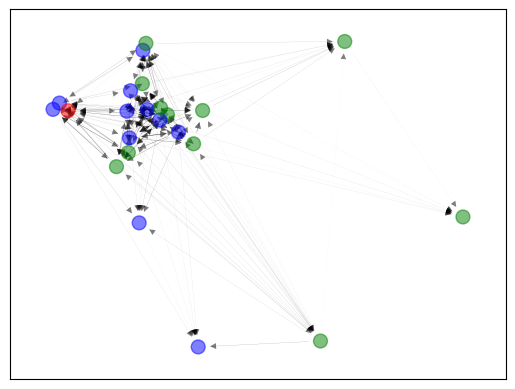

In [62]:
sample_graph = g['graph'].sample(1).iloc[0]
col_dict = {0:'red', 1:'blue', -1: 'green'}
colors = [col_dict.get(val) for key, val in dict(nx.get_node_attributes(sample_graph, "team_deffinition")).items()]
edges = sample_graph.edges(data=True)
weights = [w['weight'] for u, v, w in edges]
pos = {x[0]:[x[1], y[1]] for x, y in zip(dict(nx.get_node_attributes(sample_graph, "pos_x")).items(),dict(nx.get_node_attributes(sample_graph, "pos_y")).items())}
ec = nx.draw_networkx_edges(sample_graph, pos, width=weights, alpha=0.5)
nc = nx.draw_networkx_nodes(sample_graph, pos, node_color=colors, node_size=100, alpha=0.5)

In [63]:
#from sklearn.preprocessing import OneHotEncoder
#enc = OneHotEncoder(handle_unknown='ignore')
#enc.fit(g.y)
#enc.categories_
#enc.transform(g.y).toarray()
ohe = pd.get_dummies(g.y).astype(int)
ohe_categ = ohe.columns
ohe_vals = pd.DataFrame({'response_var': list(ohe.to_numpy())}, index=ohe.index)
g["response_var"] = ohe_vals

In [65]:
FEATURE_NUM = 8

def get_graph_tensor(row):
  sample_graph = row['graph']
  graph_tensor = from_networkx(sample_graph)
  # Convert y into a OHE-list
  graph_tensor.y = torch.Tensor(row['response_var'])
  graph_tensor.x = torch.concatenate([
      graph_tensor.action,
      graph_tensor.ke,
      graph_tensor.p,
      graph_tensor.f,
      graph_tensor.work,
      graph_tensor.team_deffinition,
      graph_tensor.pos_x,
      graph_tensor.pos_y
    ]).reshape(23,FEATURE_NUM)

  del graph_tensor['action']
  del graph_tensor['ke']
  del graph_tensor['p']
  del graph_tensor['f']
  del graph_tensor['work']
  del graph_tensor['team_deffinition']
  del graph_tensor['pos_x']
  del graph_tensor['pos_y']
  return graph_tensor

In [66]:
graphs_tensors = g.apply(get_graph_tensor, axis=1)

In [67]:
train_dataset = graphs_tensors.sample(frac=0.5)
test_dataset = graphs_tensors.drop(train_dataset.index)
val_dataset = test_dataset.sample(frac=0.5)
test_dataset = test_dataset.drop(val_dataset.index)

In [68]:
train_loader = DataLoader(train_dataset.to_list(), batch_size=32, shuffle=True)
test_loader = DataLoader(train_dataset.to_list(), batch_size=32)
val_loader = DataLoader(train_dataset.to_list(), batch_size=32)

In [69]:
import numpy as np
w = np.concatenate(train_dataset.apply(lambda x: list(x.y.numpy())).to_numpy()).reshape(train_dataset.shape[0], -1).sum(axis=0)
w = 1/w
#plt.barh(range(len(w)),w)
w[w == np.inf] = 0
w = torch.Tensor(w/w.sum())

<BarContainer object of 2 artists>

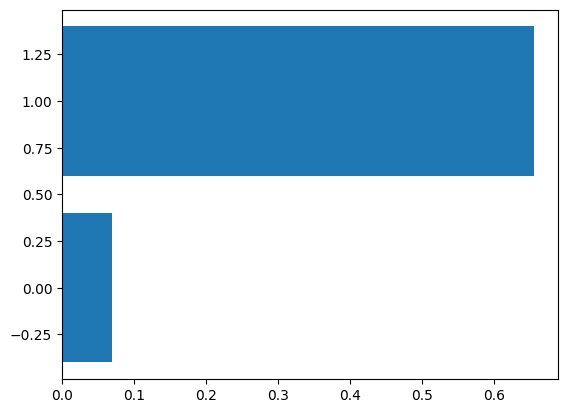

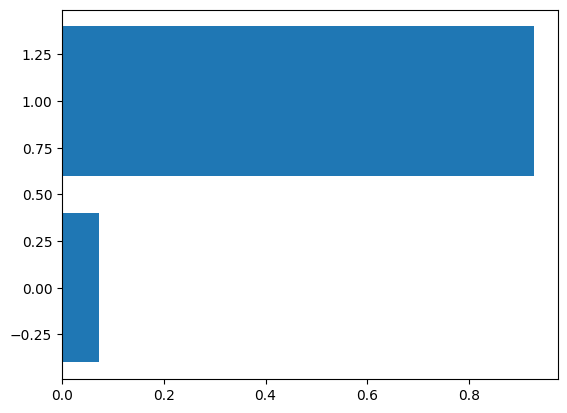

In [70]:
np.log(w + 1)
plt.barh(range(len(w)),np.log(w+1))
plt.figure()
plt.barh(range(len(w)),w)

In [74]:
FEATURE_NUM

8

In [75]:
class Net(torch.nn.Module):
    def __init__(self):
        super().__init__()
        conv_dim = 32
        self.conv1 = GCNConv(FEATURE_NUM, conv_dim)
        self.conv2 = GCNConv(conv_dim, conv_dim)
        self.conv3 = GCNConv(conv_dim, conv_dim)
        self.conv4 = GCNConv(conv_dim, conv_dim)
        self.pool = GraphMultisetTransformer(conv_dim*4, k=10, heads=4)
        self.lin1 = Linear(conv_dim*4, 64)
        self.lin2 = Linear(64, 16)
        self.lin3 = Linear(16, 2)
        self.softmax = Softmax(dim=-1)

    def forward(self, x0, edge_index, edge_weight, batch):
        scaled_edge_weight = edge_weight*10
        x1 = self.conv1(x0, edge_index, scaled_edge_weight).relu()
        x2 = self.conv2(x1, edge_index, scaled_edge_weight).relu()
        x3 = self.conv3(x2, edge_index, scaled_edge_weight).relu()
        x4 = self.conv4(x3, edge_index, scaled_edge_weight).relu()

        x = torch.cat([x1, x2, x3, x4], dim=-1)
        x = self.pool(x, batch)
        x = self.lin1(x).relu()
        x = F.dropout(x, p=0.05, training=self.training)
        x = self.lin2(x).relu()
        x = F.dropout(x, p=0.05, training=self.training)
        x = self.lin3(x)
        x = self.softmax(x)
        return x


@torch.no_grad()
def test(loader):
    model.eval()
    total_correct = 0
    for data in loader:
        data = data.to(device)
        model_result = model(data.x, data.edge_index, data.weight, data.batch)
        shapes = (model_result.shape)
        total_correct += int((model_result.argmax(dim=-1) == data.y.reshape(shapes[0],shapes[1]).argmax(dim=-1)).sum())
    return total_correct / len(loader.dataset)


def train():
  loss = CrossEntropyLoss(w)
  model.train()
  total_loss = 0
  for data in train_loader:
    data=data.to(device)
    model_result = model(data.x, data.edge_index, data.weight, data.batch)
    shapes = (model_result.shape)

    #print(shapes)
    #print(data.x.shape, data.y.shape)

    optimizer.zero_grad()
    output = loss(model_result, data.y.reshape(shapes[0],shapes[1]))
    output.backward()
    total_loss += data.num_graphs * float(output)
    optimizer.step()
  return total_loss / len(train_dataset)

In [76]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Net().to(device)

In [77]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

times = []
for epoch in range(1, 100):
    start = time.time()
    train_loss = train()
    train_acc = test(train_loader)
    val_acc = test(val_loader)
    test_acc = test(test_loader)
    print(f'Epoch: {epoch:03d}, Loss: {train_loss:.4f}, '
          f'Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}, Train Acc: {train_acc}')

    times.append(time.time() - start)
print(f"Median time per epoch: {torch.tensor(times).median():.4f}s")

Epoch: 001, Loss: 0.0813, Val Acc: 0.5941, Test Acc: 0.5941, Train Acc: 0.5940501503042745
Epoch: 002, Loss: 0.0754, Val Acc: 0.5665, Test Acc: 0.5665, Train Acc: 0.5664821467849549
Epoch: 003, Loss: 0.0737, Val Acc: 0.5858, Test Acc: 0.5858, Train Acc: 0.5858384045751155
Epoch: 004, Loss: 0.0731, Val Acc: 0.6484, Test Acc: 0.6484, Train Acc: 0.648379646601657
Epoch: 005, Loss: 0.0726, Val Acc: 0.6397, Test Acc: 0.6397, Train Acc: 0.6397463157122957
Epoch: 006, Loss: 0.0714, Val Acc: 0.6097, Test Acc: 0.6097, Train Acc: 0.6096854608109099
Epoch: 007, Loss: 0.0705, Val Acc: 0.6063, Test Acc: 0.6063, Train Acc: 0.606331109318865
Epoch: 008, Loss: 0.0700, Val Acc: 0.6944, Test Acc: 0.6944, Train Acc: 0.6943874184324363
Epoch: 009, Loss: 0.0702, Val Acc: 0.6357, Test Acc: 0.6357, Train Acc: 0.6357320917955862
Epoch: 010, Loss: 0.0698, Val Acc: 0.7351, Test Acc: 0.7351, Train Acc: 0.7351345406554732
Epoch: 011, Loss: 0.0693, Val Acc: 0.7235, Test Acc: 0.7235, Train Acc: 0.7235317838551213
E

In [78]:
for data in test_loader:
  data = data.to(device)
  model.eval()
  model_result = model(data.x, data.edge_index, data.weight, data.batch)
  break

shapes = (model_result.shape)
model_result

tensor([[1.0000e+00, 1.3742e-21],
        [1.0000e+00, 0.0000e+00],
        [1.0000e+00, 0.0000e+00],
        [1.0000e+00, 0.0000e+00],
        [1.0000e+00, 0.0000e+00],
        [1.0000e+00, 0.0000e+00],
        [1.0000e+00, 0.0000e+00],
        [1.0000e+00, 2.4242e-43],
        [1.0000e+00, 2.3899e-31],
        [1.0000e+00, 0.0000e+00],
        [1.0000e+00, 0.0000e+00],
        [1.0000e+00, 0.0000e+00],
        [1.0000e+00, 0.0000e+00],
        [1.0000e+00, 0.0000e+00],
        [1.0000e+00, 1.0790e-43],
        [1.0000e+00, 0.0000e+00],
        [1.0000e+00, 5.7498e-36],
        [1.0000e+00, 0.0000e+00],
        [1.0000e+00, 0.0000e+00],
        [1.0000e+00, 1.3618e-41],
        [1.0000e+00, 0.0000e+00],
        [1.0000e+00, 0.0000e+00],
        [1.0000e+00, 0.0000e+00],
        [1.0000e+00, 0.0000e+00],
        [1.0000e+00, 0.0000e+00],
        [1.0000e+00, 8.2635e-20],
        [1.0000e+00, 0.0000e+00],
        [1.0000e+00, 0.0000e+00],
        [1.0000e+00, 0.0000e+00],
        [1.000

<Axes: >

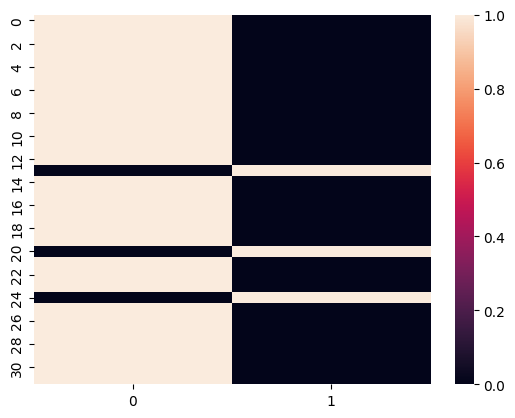

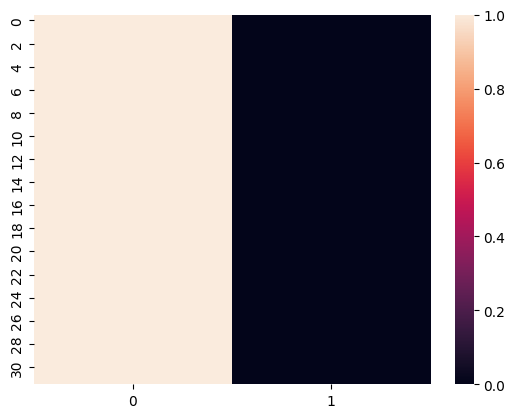

In [79]:
import seaborn as sns
sns.heatmap(data.y.reshape(shapes[0],shapes[1]).numpy())
plt.figure()
sns.heatmap(model_result.detach().numpy())

In [54]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [4]:
1

1